In [36]:
from langgraph.graph import StateGraph,START, END
from langchain_ollama import ChatOllama
from pydantic import BaseModel,Field
from typing import TypedDict,Literal

In [37]:
general_model = ChatOllama(
    model='qwen2.5:1.5b',
    temperature=1
)

json_model = ChatOllama(
    model = 'qwen2.5:1.5b',
    temperature=0,
    format='json'
)

In [38]:
class ModelSchema(BaseModel):
    sentiment:Literal['Positive','Negative'] = Field(description='the sentiment alanysis based on the given review.')

class DiagnosisSchema(BaseModel):
    tone: str = Field(description="Tone of the user's review")
    urgency: str = Field(description="how urgent the issue to resove it will it be resolved later or need to resolve right now.")
    type_of_problem: str = Field(description="This field is about the type of problem like-bug, app crash etc.")

In [39]:
structured_json_model = json_model.with_structured_output(ModelSchema)
diagnosis_structured_json_model = json_model.with_structured_output(DiagnosisSchema)

In [40]:
class State(TypedDict):
    review: str = Field(description="review of the user about the product or software.")
    sentiment: Literal['Positive','Negative'] = Field(description="Sentiment of the review.")
    diagnosis: dict
    response: str = Field(description="Give a final response to the user.")

In [63]:
def get_sentiment(state: State):
    prompt = f"Give a sentiment analysis of the given review in either positive or negative (use only single word). {state['review']}"
    response = structured_json_model.invoke(prompt)
    return {'sentiment': response.sentiment}

def check_condition(state:State) -> Literal['positive_response','diagnosis']:
    sentiment = state['sentiment']
    return 'positive_response' if sentiment == "Positive" else 'diagnosis'

def positive_response(state:State):
    prompt= f"Given a review and create a thankful response for the user to send the user.\nreview : \n{state['review']}"
    review= general_model.invoke(prompt)
    return {'response':review.content}

def diagnosis(state:State):
    prompt = f"given the review:\n{state['review']}\nYou need to find out the tone, type of issue and urgency based on this review."
    response = diagnosis_structured_json_model.invoke(prompt)
    return {'diagnosis': response.model_dump_json()}

def negative_response(state:State):
    prompt = f"Given the review:\n{state['review']} write a response to the user for there bad experience and that we will resolve your issue very soon now."
    response = general_model.invoke(prompt)
    return {'response': response.content}

In [64]:
graph = StateGraph(State)

graph.add_node('get_sentiment',get_sentiment)
graph.add_node("positive_response",positive_response)
graph.add_node('negative_response',negative_response)
graph.add_node('diagnosis',diagnosis)

graph.add_edge(START,'get_sentiment')
graph.add_conditional_edges('get_sentiment',check_condition)
graph.add_edge('positive_response',END)
graph.add_edge('diagnosis','negative_response')
graph.add_edge('negative_response',END)

workflow = graph.compile()

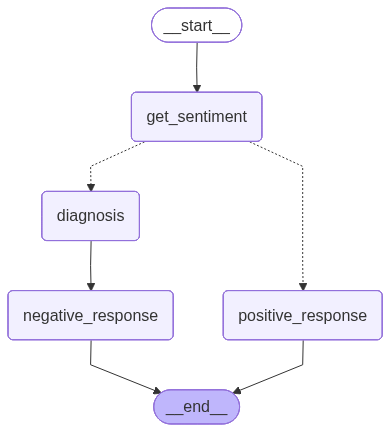

In [65]:
workflow

In [66]:
positive_review = """
I've been using this software for several months, and my experience has been excellent. The interface is intuitive, making it easy to learn and use without extensive training. Performance is fast and reliable, and the features cover all of my day-to-day needs. Customer support has been responsive whenever I've had questions, and regular updates show that the development team is actively improving the product. Overall, I would highly recommend this software to anyone looking for a dependable and user-friendly solution.
"""

negative_review = """
Unfortunately, my experience with this software has been disappointing. The interface feels outdated and can be difficult to navigate, especially for new users. I've encountered several bugs that affected productivity, and performance sometimes slows down when handling larger tasks. While the software offers useful features, many of them feel incomplete or poorly implemented. Customer support response times have also been slower than expected. Unless significant improvements are made, I would hesitate to recommend this product.
"""

initial_state = {
    'review' : positive_review
}
result = workflow.invoke(initial_state)

In [67]:
result

{'review': "\nI've been using this software for several months, and my experience has been excellent. The interface is intuitive, making it easy to learn and use without extensive training. Performance is fast and reliable, and the features cover all of my day-to-day needs. Customer support has been responsive whenever I've had questions, and regular updates show that the development team is actively improving the product. Overall, I would highly recommend this software to anyone looking for a dependable and user-friendly solution.\n",
 'sentiment': 'Positive',
 'response': "Thank you so much for your kind words! It means a lot to know that our software has met your needs and exceeded expectations. We appreciate your feedback and look forward to continuing to improve it even further. If there's anything else we can do for you, please don't hesitate to reach out.\n\nBest regards,\n[Your Name]"}